In [1]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.NucleationAndPropagationMeasurements import replace_ugly_long_name
from src.quanta_utils import get_neighbors
from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mixSpiCalc import mixSpiCalc

## Sensitivity analysis

In [ ]:
def simple_treatment(name):
    # if "field" in name.lower():
    #     return "FB"
    if "nec" in name.lower():
        return "NecrosisInColonies"
    elif "apop" in name.lower():
        return "ApoptosisInColonies"
    else:
        if "_A" in name:
            return "MixedSubApop"
        elif "_N" in name:
            return "MixedSubNec"
        return "MixedColony"

In [3]:
exps_dir_name = "/home/esraan/CellDeathSpreading/data/mixed_pure_death_minutes_microns"
meta_data_file_full_path= "/home/esraan/CellDeathSpreading/data/csv_files_minutes_microns_live_only_no_apop.csv"# "/sise/assafzar-group/assafzar/Esraa/Others/UpdatedMetaData.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
all_previous_experiments_spi_and_ni_regeneration = calc_all_experiments_SPI_and_NI_for_landscape(list(exp_names),exps_dir_path=exps_dir_name,
                                                                                                 meta_data_full_file_path=meta_data_file_full_path,
                                                                                                 dist_threshold=100,
                                                                                                 filter_neighbors_by_distance = 1,
                                                                                                 filter_neighbors_by_level = 1,)
reformatting_all_previos_experiments_spi_and_ni_regeneration = {"Experiment_name":[],
                                                                "SPI":[],
                                                                "NI":[],
                                                                "Treatment":[],
                                                                "Cell Line + Treatment":[],
                                                                "Cell Line":[],
                                                                "Origin":[],
                                                                "Mode":[],
                                                                "Density":[],
                                                                "pvalue":[]}
for key,value in all_previous_experiments_spi_and_ni_regeneration.items():
    if value is None or "--19" in key or "mixed" in simple_treatment(key):
        continue
    origin = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Origin"].values[0]
    mode = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Mode"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Origin"].append(origin)
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Mode"].append(mode)
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Experiment_name"].append(key)
    exp_cell_line= meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"]== key]["Cell Line"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["SPI"].append(value[0])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["NI"].append(value[1])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["pvalue"].append(value[2])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line"].append(exp_cell_line)
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line + Treatment"].append(replace_ugly_long_name(key,exp_cell_line))
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Treatment"].append(simple_treatment(key))
    density = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Density(#Cells)"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Density"].append(density)

In [4]:
only_recent_death_flag_for_neighbors_calc = False
# sliding_time_window_size = 20
exps_dir_name = "/home/esraan/CellDeathSpreading/data/mixed_pure_death_minutes_microns"
meta_data_file_full_path= "/home/esraan/CellDeathSpreading/data/csv_files_minutes_microns_live_only_no_apop.csv"#
meta_data_extract_exp_names = pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:, 1]
meta_data_df = pd.read_csv(meta_data_file_full_path)

final_dataframe = pd.DataFrame()

for neighbors_dist_threshold in (33, 50, 100, 150, 200):
    for sliding_time_window_size in (5, 10, 30, 60, 90, 120):
        p_nucs_by_exp_name = {}
        global_density_by_exp_name = {}
        all_previous_experiments_spi_and_ni_regeneration = calc_all_experiments_SPI_and_NI_for_landscape(
            exp_name=list(exp_names),
            exps_dir_path=exps_dir_name,
            meta_data_full_file_path=meta_data_file_full_path,
            dist_threshold=neighbors_dist_threshold,
            only_recent_death_flag_for_neighbors_calc=only_recent_death_flag_for_neighbors_calc,
            time_unit="minutes",
            sliding_time_window_size=sliding_time_window_size
        )
        reformatting_all_previos_experiments_spi_and_ni_regeneration = {"Experiment_name": [],
                                                                        "SPI": [],
                                                                        "NI": [],
                                                                        "Treatment": [],
                                                                        "Cell Line + Treatment": [],
                                                                        "Cell Line": [],
                                                                        "Origin": [],
                                                                        "Mode": [],
                                                                        "Density": [],
                                                                        "pvalue": [],
                                                                        "sliding_time_window_size": [],
                                                                        "neighbors_dist_threshold": []}
        for key, value in all_previous_experiments_spi_and_ni_regeneration.items():
            if value is None:
                continue
            origin = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Origin"].values[0]
            mode = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Mode"].values[0]
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Origin"].append(origin)
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Mode"].append(mode)
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Experiment_name"].append(key)
            exp_cell_line = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Cell Line"].values[0]
            reformatting_all_previos_experiments_spi_and_ni_regeneration["SPI"].append(value[0])
            reformatting_all_previos_experiments_spi_and_ni_regeneration["NI"].append(value[1])
            reformatting_all_previos_experiments_spi_and_ni_regeneration["pvalue"].append(value[2])
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line"].append(exp_cell_line)
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line + Treatment"].append(replace_ugly_long_name(key, exp_cell_line))
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Treatment"].append(simple_treatment(key))
            density = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Density(#Cells)"].values[0]
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Density"].append(density)
            reformatting_all_previos_experiments_spi_and_ni_regeneration["sliding_time_window_size"].append(sliding_time_window_size)
            reformatting_all_previos_experiments_spi_and_ni_regeneration["neighbors_dist_threshold"].append(neighbors_dist_threshold)
        
        reformatting_all_previos_experiments_spi_and_ni_regeneration_df = pd.DataFrame(reformatting_all_previos_experiments_spi_and_ni_regeneration)
        merged_df = reformatting_all_previos_experiments_spi_and_ni_regeneration_df[reformatting_all_previos_experiments_spi_and_ni_regeneration_df["Origin"] != 'field3_colony']
        # merged_df['segregationIndex'] = merged_df.apply(
        #     lambda row: plot_res_dict.get(row['Origin'], {}).get(row['Mode'].lower(), None),
        #     axis=1
        # )
        final_dataframe = pd.concat([final_dataframe, merged_df], ignore_index=True)

/home/esraan/CellDeathSpreading/src/uSpiCalc.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  self.propagation_index = ((self.scramble_signficance_95 - self.original_difference_death_times) / self.scramble_signficance_95)
/home/esraan/CellDeathSpreading/src/uSpiCalc.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  self.propagation_index = ((self.scramble_signficance_95 - self.original_difference_death_times) / self.scramble_signficance_95)
/home/esraan/CellDeathSpreading/src/uSpiCalc.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  self.propagation_index = ((self.scramble_signficance_95 - self.original_difference_death_times) / self.scramble_signficance_95)
/home/esraan/CellDeathSpreading/src/uSpiCalc.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  self.propagation_index = ((self.scramble_signficance_95 - self.original_difference_death_times) / self.scramble_signficance_95)
/home/esraan/CellDeathSpreading/

In [5]:
final_dataframe.to_csv("/home/esraan/CellDeathSpreading/results/AllExperimentsSPI&NI&SAupdated.csv", index=False)

In [6]:
filtered_df = final_dataframe[
    ~final_dataframe['Experiment_name'].str.contains('pure|mix|SKT', case=False)
]

In [7]:
filtered_df.to_csv("/home/esraan/CellDeathSpreading/results/FilteredAllExperimentsSPI&NI&SAupdated_updated.csv", index=False)

## reading summery file

In [28]:
filtered_df = pd.read_csv("/home/esraan/CellDeathSpreading/results/AllExperimentsSPI&NI&SAupdated.csv")

In [29]:
filtered_df = filtered_df[(~filtered_df['Experiment_name'].str.contains('pure|colony|SKT|outl|ROI#2|mixed', case=False, na=False))]#& ~filtered_df['Origin'].str.contains('field14_two_colony'))]
# filtered_df = filtered_df[filtered_df['neighbors_dist_threshold'] < 200]
# filtered_df = filtered_df[filtered_df['sliding_time_window_size'] <= 90]
filtered_df

,Experiment_name,SPI,NI,Treatment,Cell Line + Treatment,Cell Line,Origin,Mode,Density,pvalue,sliding_time_window_size,neighbors_dist_threshold
0,field13_crop-001_ROI#1_annotation_apop.csv,0.100299,0.257384,ApoptosisInColonies,MCF10A+field13_crop-001_roi#1_annotation_apop.csv,MCF10A,field13_colony,Apoptosis,237,0.000,5,33
1,field13_crop-001_ROI#1_annotation_nec.csv,0.376201,0.142395,NecrosisInColonies,MCF10A+field13_crop-001_roi#1_annotation_nec.csv,MCF10A,field13_colony,Necrosis,309,0.000,5,33
2,Field14-002_ROI#1_annotation_apop.csv,0.204739,0.239691,ApoptosisInColonies,MCF10A+field14-002_roi#1_annotation_apop.csv,MCF10A,field14_colony,Apoptosis,387,0.000,5,33
3,Field14-002_ROI#1_annotation_nec.csv,0.418797,0.212851,NecrosisInColonies,MCF10A+field14-002_roi#1_annotation_nec.csv,MCF10A,field14_colony,Necrosis,249,0.000,5,33
4,7-20-23_10arednuclei_ROI#10_annotation_apop.csv,-1.199005,0.553191,ApoptosisInColonies,MCF10A+7-20-23_10arednuclei_roi#10_annotation_...,MCF10A,field11_colony,Apoptosis,47,0.761,5,33
...,...,...,...,...,...,...,...,...,...,...,...,...
496,Field14-002_ROI#1_annotation_nec.csv,0.134615,0.220884,NecrosisInColonies,MCF10A+field14-002_roi#1_annotation_nec.csv,MCF10A,field14_colony,Necrosis,249,0.000,120,200
497,7-20-23_10arednuclei_ROI#10_annotation_apop.csv,0.091584,0.170213,ApoptosisInColonies,MCF10A+7-20-23_10arednuclei_roi#10_annotation_...,MCF10A,field11_colony,Apoptosis,47,0.003,120,200
498,7-20-23_10arednuclei_ROI#10_annotation_nec.csv,0.278571,0.225352,NecrosisInColonies,MCF10A+7-20-23_10arednuclei_roi#10_annotation_...,MCF10A,field11_colony,Necrosis,142,0.000,120,200
499,7-20-23_10arednuclei_ROI#13_or14_both_colonies...,0.252824,0.157258,ApoptosisInColonies,MCF10A+7-20-23_10arednuclei_roi#13_or14_both_c...,MCF10A,field14_two_colony,Apoptosis,248,0.000,120,200


### T-test of Apoptosis SPI vs Necrosis

In [18]:
from scipy.stats import ttest_ind, ttest_rel, wilcoxon, mannwhitneyu

# Extract SPI values for necrosis and apoptosis
necrosis_spi = filtered_df[filtered_df['Treatment'] == 'NecrosisInColonies']['SPI']
apoptosis_spi = filtered_df[filtered_df['Treatment'] == 'ApoptosisInColonies']['SPI']

# Perform one-tailed t-test (necrosis > apoptosis)
t_stat, p_value = ttest_rel(necrosis_spi, apoptosis_spi, alternative='greater')
wilcoxon_stat, wilcoxon_p_value = wilcoxon(necrosis_spi, apoptosis_spi, alternative='greater',zero_method='wilcox', correction=False)
mannwhitney_stat, mannwhitney_p_value = mannwhitneyu(necrosis_spi, apoptosis_spi, alternative='greater')
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")
print(f"Wilcoxon statistic: {wilcoxon_stat}")
print(f"Wilcoxon P-value: {wilcoxon_p_value}")
print(f"Mann-Whitney statistic: {mannwhitney_stat}")
print(f"Mann-Whitney P-value: {mannwhitney_p_value}")

T-statistic: 9.835212086928617
P-value: 2.2871059660513247e-17
Wilcoxon statistic: 7175.0
Wilcoxon P-value: 8.169996970823972e-21
Mann-Whitney statistic: 13387.0
Mann-Whitney P-value: 6.3026497312031165e-31


### SPI : Sensitivity Analysis - sliding time window & neighbors distance threshold

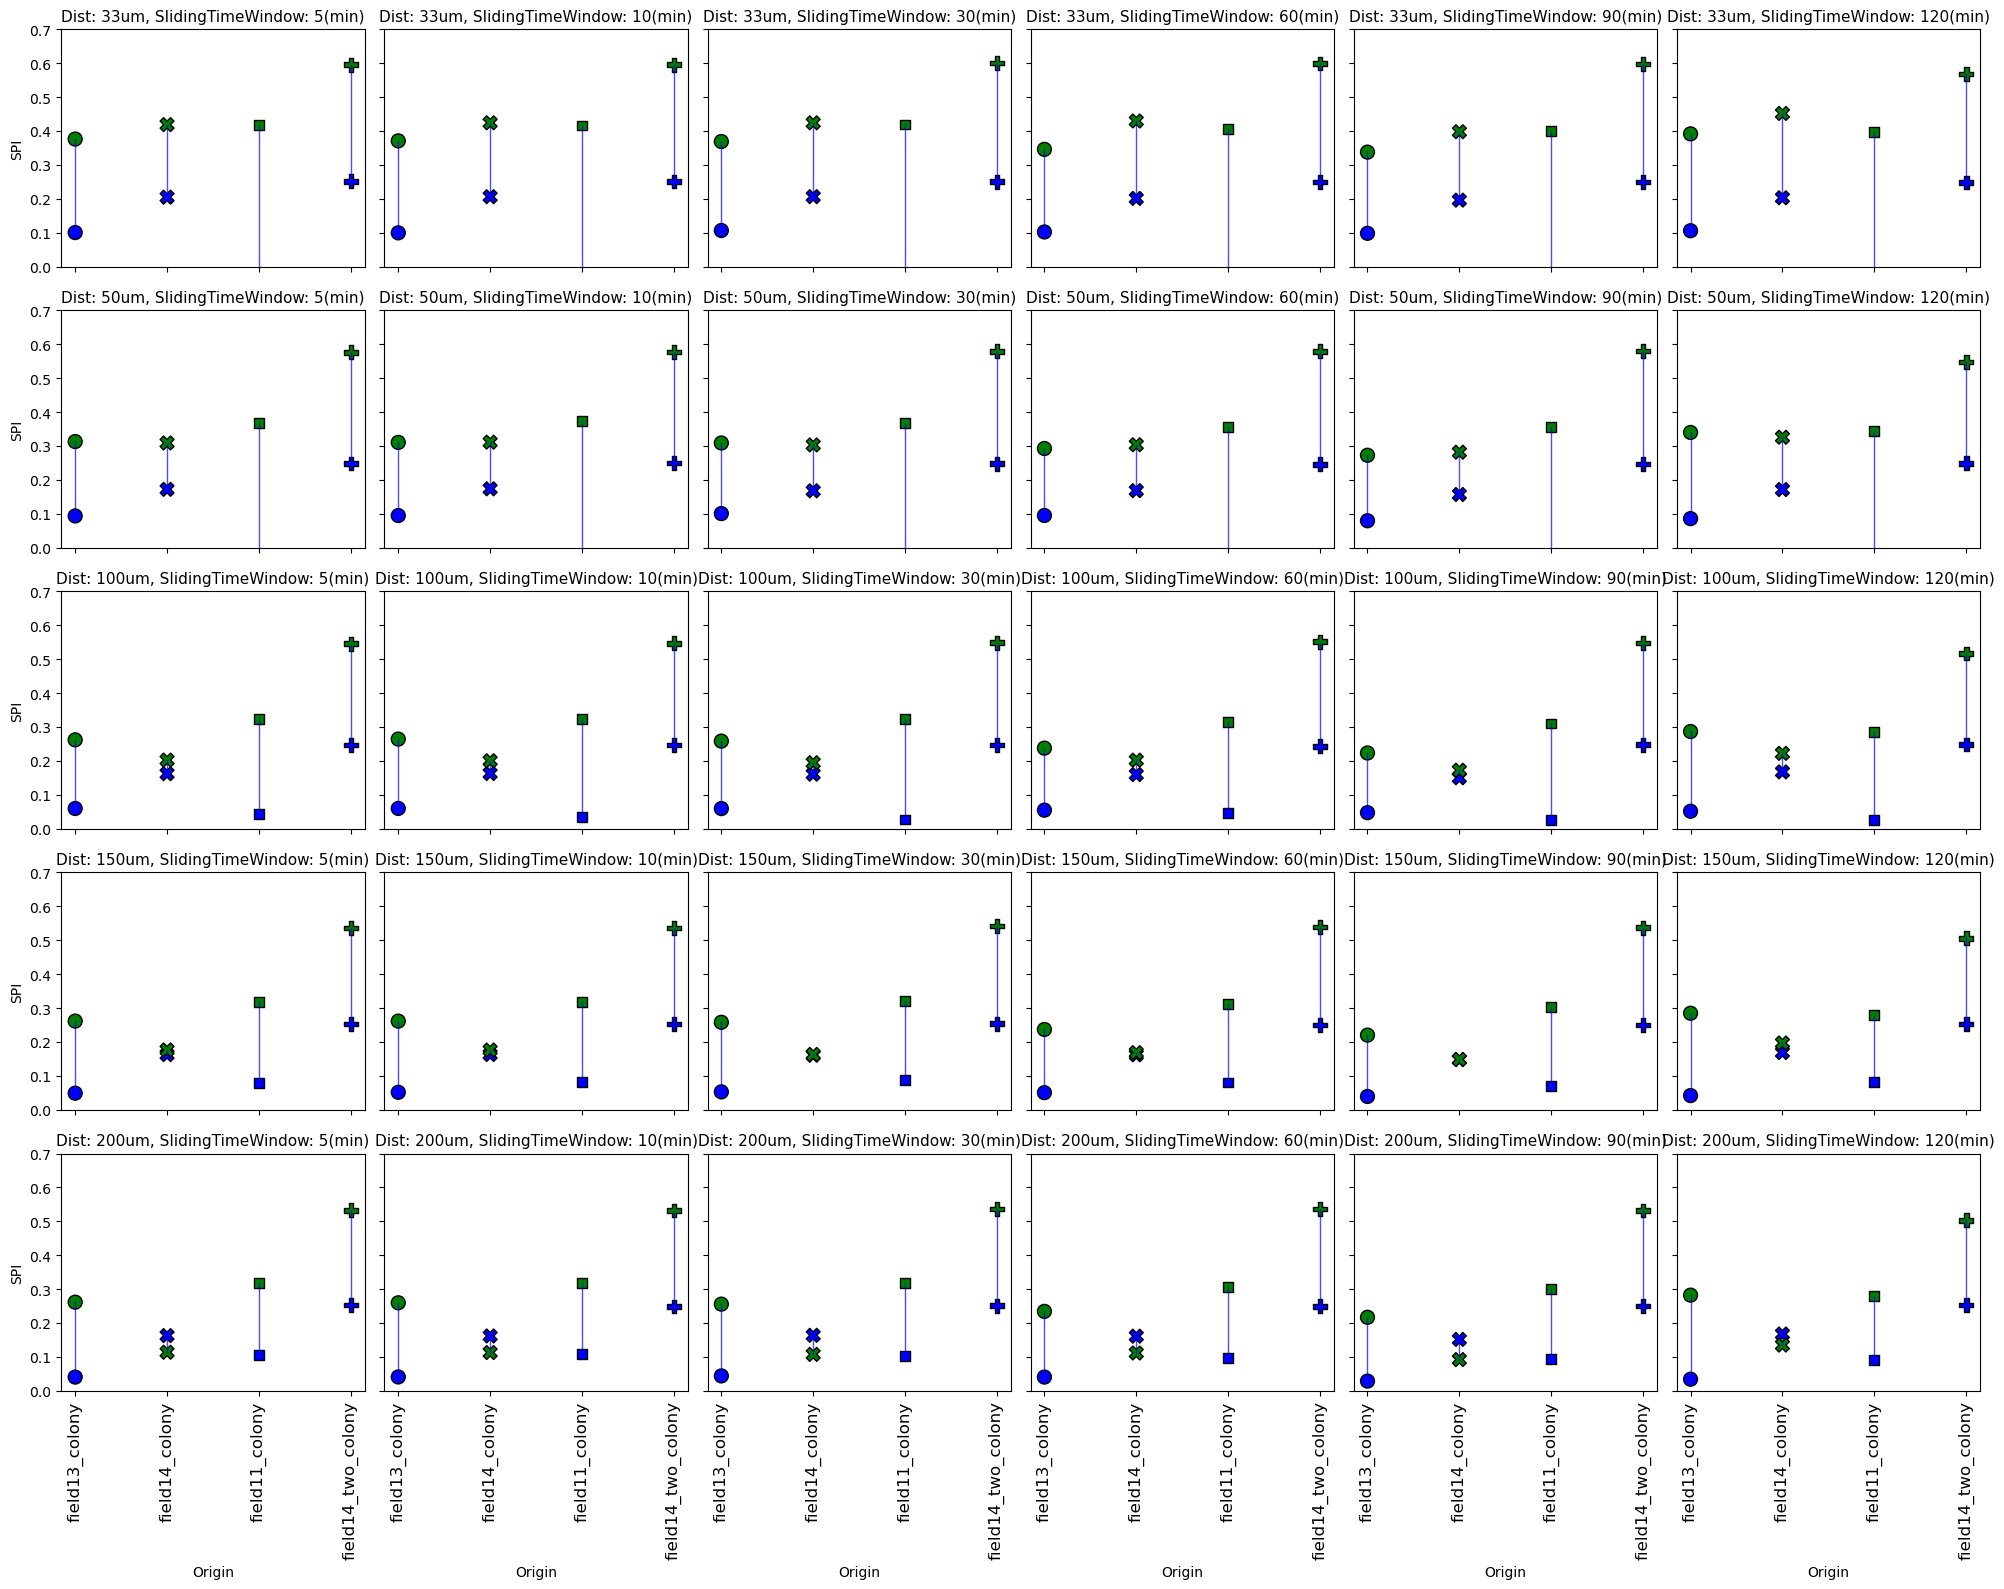

In [34]:
# Define the grid of subplots
# Define the custom palette
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(20, 16), sharex=True, sharey=True)

# Define the unique distances and sliding time windows
distances = filtered_df['neighbors_dist_threshold'].unique()
sliding_windows = filtered_df['sliding_time_window_size'].unique()

# Sort distances and sliding windows for consistent plotting
distances = sorted(distances)
sliding_windows = sorted(sliding_windows)

# Iterate over distances and sliding windows to create subplots
for i, dist in enumerate(distances):
    for j, window in enumerate(sliding_windows):
        ax = axes[i, j]
        subset = filtered_df[
            (filtered_df['neighbors_dist_threshold'] == dist) &
            (filtered_df['sliding_time_window_size'] == window)
        ]
        
        sns.scatterplot(
            data=subset,
            x="Origin",
            y="SPI",
            hue="Treatment",
            style="Origin",
            palette=custom_palette,
            edgecolor="black",
            linewidth=1,
            s=100,
            ax=ax,
            legend=False  # Suppress legend for all subplots
        )
        
        # Add connecting lines between points from the same origin
        for origin, group in subset.groupby("Origin"):
            ax.plot(group["Origin"], group["SPI"], linestyle='-', linewidth=1, alpha=0.7, color='b', )
        
        # Set subplot title
        ax.set_title(f"Dist: {dist}um, SlidingTimeWindow: {window}(min)", fontsize = 11)
        ax.set_ylim(0, 0.7)
        ax.tick_params(axis='x', labelsize=12, rotation=90)

# Add legend to the last subplot
handles, labels = axes[-1, -1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=False)
# plt.setp(axes, xticks=filtered_df['Origin'].unique(), xticklabels=filtered_df['Origin'].unique(), fontsize=12, rotation=90, ha='right')
# Adjust layout
plt.tight_layout()
plt.show()


# Spatail Propagation Index

## figure 2H

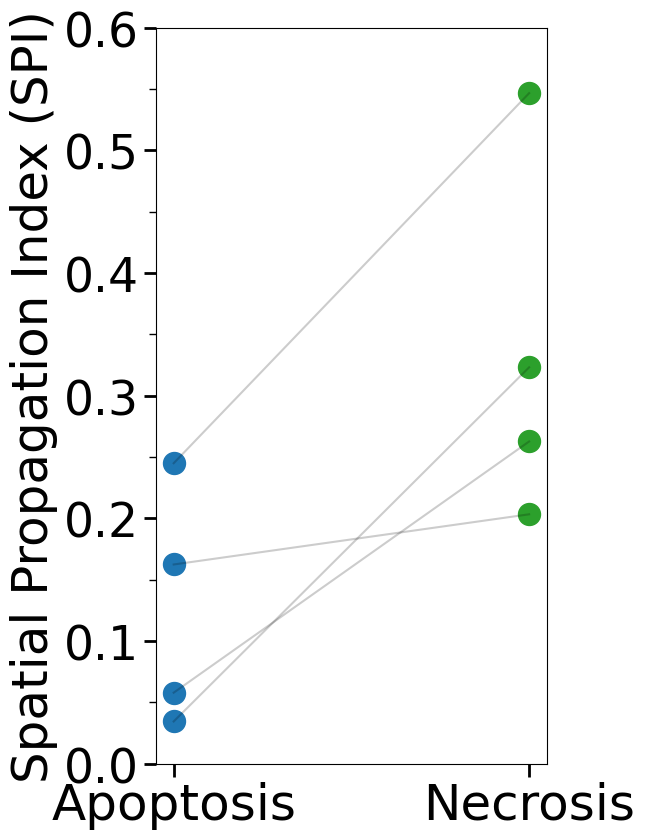

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
custom_palette =  {"ApoptosisInColonies": "#1f77b4", "NecrosisInColonies": "#2ca02c"}#{"ApoptosisInColonies": "#bf7745", "NecrosisInColonies": "#f5e18a"}
{"ApoptosisInColonies": "#1f77b4", "NecrosisInColonies": "#2ca02c"}
{"apoptosis": "#bf7745", "necrosis": "#f5e18a"}

# Replace treatment with origin and group values
# Filter the data for distance of 100 and sliding time window of 10
filtered_subset = filtered_df[
    (filtered_df['neighbors_dist_threshold'] == 100) &
    (filtered_df['sliding_time_window_size'] == 10)
]
origins = filtered_subset['Origin'].unique()
group_a_values = []
group_b_values = []
treatment_labels = []
markers = ['o', 'o', 'o', 'o'] #markers = ['o', 'x', 's', '+']
origin_marker_dict = {origin: markers[i % len(markers)] for i, origin in enumerate(origins)}
# X positions: 0 for Group A, 1 for Group B
x_a = np.zeros(len(origins))
x_b = np.ones(len(origins))
# Assign markers based on origin
origin_markers = [origin_marker_dict[origin] for origin in origins]
for origin in origins:
    subset = filtered_subset[filtered_subset['Origin'] == origin]
    group_a = subset[subset['Treatment'] == 'ApoptosisInColonies']['SPI'].mean()
    group_b = subset[subset['Treatment'] == 'NecrosisInColonies']['SPI'].mean()
    if not np.isnan(group_a) and not np.isnan(group_b):
        group_a_values.append(group_a)
        group_b_values.append(group_b)
        treatment_labels.append(origin)  # Use treatment labels instead of origin

# Plot
plt.figure(figsize=(6.5, 8.5))

for i in range(len(treatment_labels)):
    # Line connecting values
    plt.plot([x_a[i], x_b[i]], [group_a_values[i], group_b_values[i]], 'k-', alpha=0.2)
    # Group A point
    plt.scatter(x_a[i], group_a_values[i], color=custom_palette['ApoptosisInColonies'], marker=origin_markers[i], label='ApoptosisInColonies' if i == 0 else "", s=250)
    # Group B point
    plt.scatter(x_b[i], group_b_values[i], color=custom_palette['NecrosisInColonies'], marker=origin_markers[i], label='NecrosisInColonies' if i == 0 else "", s=250)

custom_legend = [Line2D([0], [0], marker=marker, color='k', markerfacecolor='k', markersize=10, label=origin)
                 for origin, marker in origin_marker_dict.items()]
# Formatting
plt.xticks([0, 1], ['Apoptosis', 'Necrosis'], fontsize=36)
plt.gca().tick_params(axis='x', which='major', length=9, width=2, labelsize=36)
plt.gca().tick_params(axis='y', which='major', length=9, width=2, labelsize=34)
plt.gca().tick_params(axis='y', which='minor', length=5, width=1)
plt.gca().set_yticks(np.arange(0.0, 0.7, 0.05), minor=True)
# plt.yticks(np.arange(0.0, 0.7, 0.05), fontsize=22)
# plt.yticks(fontsize = 22)
plt.ylabel("Spatial Propagation Index (SPI)", fontsize = 36)
# plt.title("SPI Values Across Treatments")
plt.ylim(0.0, 0.6)
plt.legend(handles=custom_legend, title="Origins", loc='lower right').remove()
plt.grid(False)
plt.tight_layout()
plt.gca().set_facecolor('none')
plt.savefig("/home/esraan/CellDeathSpreading/results/newSPIAcrossOrigins_paperf_dc_r.svg", format="svg", facecolor='none')
plt.show()


## segregation index

In [1]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/esraan/CellDeathSpreading/")

from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [2]:

single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'

### regular Segregation index

In [3]:
def plot_segregation_indices(res):
    """
    Plots segregation indices for different modes across files using scatter plot.

    Parameters:
    - res: dict, dictionary containing filenames as keys and segregation indices as values
    """
    files = list(res.keys())
    modes = list(res[files[0]].keys())  # Extract modes from the first file
    mode_values = {mode: [res[file][mode][0] for file in files] for mode in modes}  # Extract first element of tuple

    markers = ['o', 'x', 's', '+', '^', 'v']  # Define markers for files
    colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']  # Define colors for modes
    mode_color_dict = {mode: colors[i % len(colors)] for i, mode in enumerate(modes)}
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    plt.figure(figsize=(12, 6))
    for file_idx, file in enumerate(files):
        for mode in modes:
            plt.scatter(file_idx, mode_values[mode][file_idx], marker=file_marker_dict[file], color=mode_color_dict[mode], label=f"{file} - {mode}")

    plt.xticks(range(len(files)), files, rotation=45, ha='right')
    plt.title("Segregation Indices Across Files", fontsize=16)
    plt.xlabel("Files", fontsize=14)
    plt.ylabel("Segregation Index", fontsize=14)
    plt.axhline(y=1, color='red', linestyle='--', linewidth=1, label='random segregation index (1)')
    plt.legend(title="File - Mode", fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(False)
    plt.savefig("/home/esraan/CellDeathSpreading/results/SegregationIndicesAcrossFiles.svg", format="svg")
    plt.show()

3-19-2924_10ah2bmcherry_ROI#2_annotation_nec.csv
Field14-002_ROI#1_annotation_nec.csv
20181227_MCF10A_SKT_xy3.csv
20181227_MCF10A_SKT_xy5.csv
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv
{'apoptosis': (np.float64(0.9302195340501791), np.float64(0.0), np.float64(0.41680672268907565)), 'necrosis': (np.float64(0.9508885686839577), np.float64(0.0), np.float64(0.5831932773109244))}
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_nec.csv
7-20-23_10arednuclei_ROI#10_annotation_nec.csv
Field14-002_ROI#1_annotation_apop.csv
20181227_MCF10A_SKT_xy4.csv
mixcolony2_field13.csv
Field14-002_ROI#1_annotation_mixed.csv
{'apoptosis': (np.float64(0.793858132131328), np.float64(0.0), np.float64(0.6071987480438185)), 'necrosis': (np.float64(0.6813428316440363), np.float64(0.0), np.float64(0.38967136150234744)), 'entosis': (np.float64(0.19642857142857142), np.float64(0.002), np.float64(0.003129890453834116))}
7-20-23_10arednuclei_ROI#10_annotation_apop.csv
3-19-2924_10ah2bm

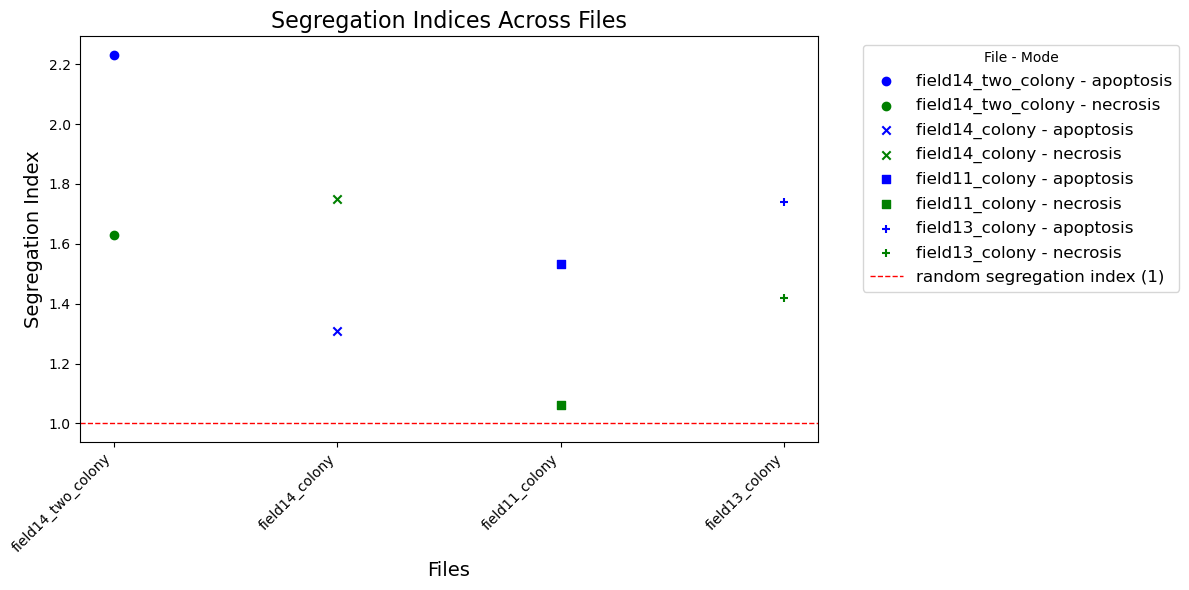

In [4]:

import os  # Ensure os module is imported
per_5 = {}
# single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_sytox/'
res_si = {}
res_ob = {}
p_values = {}
expected_lik = {}
mean_shuffled = {}
shuffle_mean_full_arrays = {}
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    print(file)
    if '_mixed' not in file:
        continue
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    exp_full_path = os.path.join(single_exp_full_paths, file)
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100
    death_modes = csv_file[["Mode"]].values
    segregation_index = SegregationIdx(cells_loci, death_modes, 1000, dist_threshold, filter_neighbors_by_distance=True, neighbors_level=1, stats_to_calculate="mean")
    seg_res_dict = segregation_index.get_segregation_index(num_permutations = 1000)
    distr_dict = segregation_index.permuted_si
    new_file = file
    print(seg_res_dict)
    per_5[file] = {key: np.percentile(sorted(value),95) for key, value in distr_dict.items() if key in ('apoptosis', 'necrosis')}
    mean_shuffled[file] = {key: np.mean(value) for key, value in distr_dict.items() if key in ('apoptosis', 'necrosis')}
    shuffle_mean_full_arrays [file] = {key: value for key, value in distr_dict.items() if key in ('apoptosis', 'necrosis')}
    res_si[file] = {key: ((value[0] / value[2]), value[1]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')}
    res_ob[file] =  {key: (value[0]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')}
    p_values[file] = {key: (value[1]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')}
    expected_lik[file] = {key: (value[2]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')}

new_res = {
    '7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
    'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
    '7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
    'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'
}
plot_res_dict = {new_res.get(key, key): value for key, value in res_si.items()}  # Provide default key if not found

import matplotlib.pyplot as plt



# Example usage

plot_segregation_indices(plot_res_dict)

In [5]:
# Convert dictionaries to DataFrame
data = []

# Iterate over the file names in new_res
for file_name, origin in new_res.items():
    for mode in ['apoptosis', 'necrosis']:
        data.append({
            'File Name': file_name,
            'Origin': origin,
            'Mode': mode,
            'Observed': res_ob.get(file_name, {}).get(mode, None),
            'Expected': expected_lik.get(file_name, {}).get(mode, None),
            'Percentile_95': per_5.get(file_name, {}).get(mode, None),
            'Segregation Index': plot_res_dict.get(origin, {}).get(mode, (None,))[0],
            'Mean Shuffled': mean_shuffled.get(file_name, {}).get(mode, None),
            'Shuffle Mean Full Arrays': shuffle_mean_full_arrays.get(file_name, {}).get(mode, None),
            'p-value': p_values.get(file_name, {}).get(mode, None)
        })

# Create a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
df

,File Name,Origin,Mode,Observed,Expected,Percentile_95,Segregation Index,Mean Shuffled,Shuffle Mean Full Arrays,p-value
0,7-20-23_10arednuclei_ROI#13_or14_both_colonies...,field14_two_colony,apoptosis,0.930220,0.416807,0.439919,2.231777,0.415322,"[0.4224734383000512, 0.41480254736303124, 0.43...",0.0
1,7-20-23_10arednuclei_ROI#13_or14_both_colonies...,field14_two_colony,necrosis,0.950889,0.583193,0.601271,1.630486,0.582264,"[0.5711380998124514, 0.5798122226796578, 0.601...",0.0
2,Field14-002_ROI#1_annotation_mixed.csv,field14_colony,apoptosis,0.793858,0.607199,0.623428,1.307411,0.606378,"[0.598437244313533, 0.598552814596629, 0.61365...",0.0
3,Field14-002_ROI#1_annotation_mixed.csv,field14_colony,necrosis,0.681343,0.389671,0.413306,1.748506,0.388305,"[0.39117320653465226, 0.3790931402377185, 0.41...",0.0
4,7-20-23_10arednuclei_ROI#10_annotation_mixed.csv,field11_colony,apoptosis,0.380750,0.248677,0.301746,1.531100,0.243444,"[0.2332657885849375, 0.19032421479229988, 0.21...",0.0
5,7-20-23_10arednuclei_ROI#10_annotation_mixed.csv,field11_colony,necrosis,0.798343,0.751323,0.771865,1.062583,0.749622,"[0.7386317907444667, 0.7490442655935613, 0.742...",0.0
6,field13_crop-001_ROI#1_annotation_mixed.csv,field13_colony,apoptosis,0.755678,0.434066,0.456709,1.740929,0.433239,"[0.4542227580202263, 0.4155917219208358, 0.468...",0.0
7,field13_crop-001_ROI#1_annotation_mixed.csv,field13_colony,necrosis,0.803803,0.565934,0.584014,1.420311,0.565307,"[0.5800662659885961, 0.5490907689936817, 0.589...",0.0


In [6]:
df.to_csv("/home/esraan/CellDeathSpreading/results/SegregationIndicesFullP_values_full_adjusted.csv", index=False)

### Expected vs Observed plots:

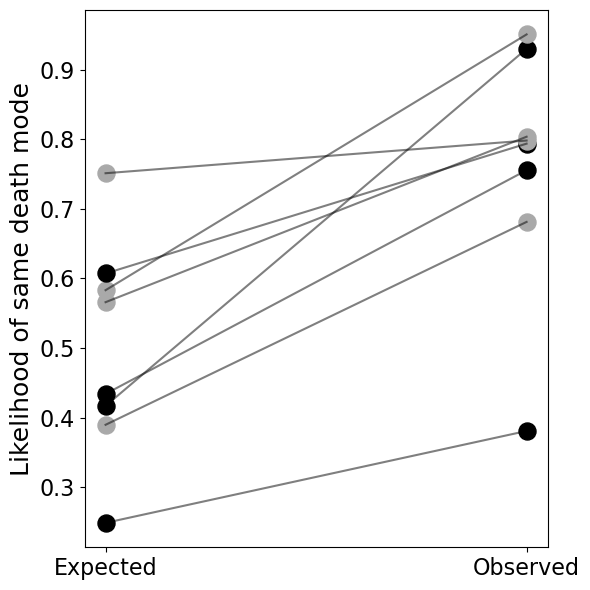

In [40]:
# Prepare data for plotting
custom_palette = {'apoptosis': 'black', 'necrosis': 'darkgrey'}
x_expected = [0] * len(df)  # Expected is always at x=0
x_observed = [1] * len(df)  # Observed is always at x=1
y_values = df['Observed'].tolist()  # Actual observed values for y-axis
colors = [custom_palette[mode] for mode in df['Mode']]  # Color based on mode
markers = [origin_marker_dict[origin] for origin in df['Origin']]  # Marker based on origin

# Plot
plt.figure(figsize=(6, 6))

for i in range(len(df)):
    # Line connecting observed and expected
    plt.plot([x_expected[i], x_observed[i]], [df['Expected'].iloc[i], y_values[i]], color='k', alpha=0.5)
    # Observed point
    plt.scatter(x_observed[i], y_values[i], color=colors[i], marker=markers[i], s=150, label='Observed' if i == 0 else "")
    # Expected point
    plt.scatter(x_expected[i], df['Expected'].iloc[i], color=colors[i], marker=markers[i], s=150, label='Expected' if i == 0 else "")

# Formatting
plt.xticks([0.0, 1.0], ['Expected', 'Observed'], fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel("Likelihood of same death mode", fontsize=18)
# plt.title("Observed vs Expected Values", fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


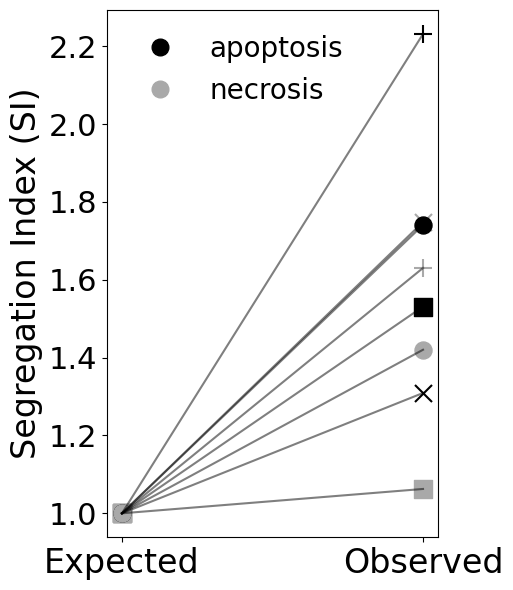

In [ ]:
# Prepare data for plotting
custom_palette = {'apoptosis': 'black', 'necrosis': 'darkgrey'}
x_expected = [0] * len(df)  # Expected is always at x=0
x_observed = [1] * len(df)  # Observed is always at x=1
y_values = (df['Observed'] / df['Expected']).tolist()  # Divide observed by percentile
expected_values = (df['Expected'] / df['Expected']).tolist()  # Divide expected by percentile
colors = [custom_palette[mode] for mode in df['Mode']]  # Color based on mode
markers = [origin_marker_dict[origin] for origin in df['Origin']]  # Marker based on origin

# Plot
plt.figure(figsize=(5.2, 6))

for i in range(len(df)):
    # Line connecting observed and expected
    plt.plot([x_expected[i], x_observed[i]], [expected_values[i], y_values[i]], color='k', alpha=0.5)
    # Observed point
    plt.scatter(x_observed[i], y_values[i], color=colors[i], marker=markers[i], s=150, label='Observed' if i == 0 else "")
    # Expected point
    plt.scatter(x_expected[i], expected_values[i], color=colors[i], marker=markers[i], s=150, label='Expected' if i == 0 else "")

# Formatting

plt.xticks([0, 1], ['Expected', 'Observed'], fontsize=24)
plt.ylabel("Segregation Index (SI)", fontsize=24)
plt.yticks(fontsize=22)
# plt.title("Observed vs Expected Values (Normalized)", fontsize=16)
plt.grid(False)
# Define custom legend handles
custom_legend = [
    Line2D([0], [0], marker='o', color='black', label='apoptosis', markersize=12, linestyle='None'),
    Line2D([0], [0], marker='o', color='darkgrey', label='necrosis', markersize=12, linestyle='None')
]

# Add the custom legend to the plot
plt.legend(handles=custom_legend, title="", loc='upper left', fontsize=20, frameon=False)
plt.tight_layout()
plt.gca().set_facecolor('none')
plt.savefig(f"/home/esraan/CellDeathSpreading/results/SIbg_legend240625251855.svg", format="svg",facecolor='none')
plt.show()


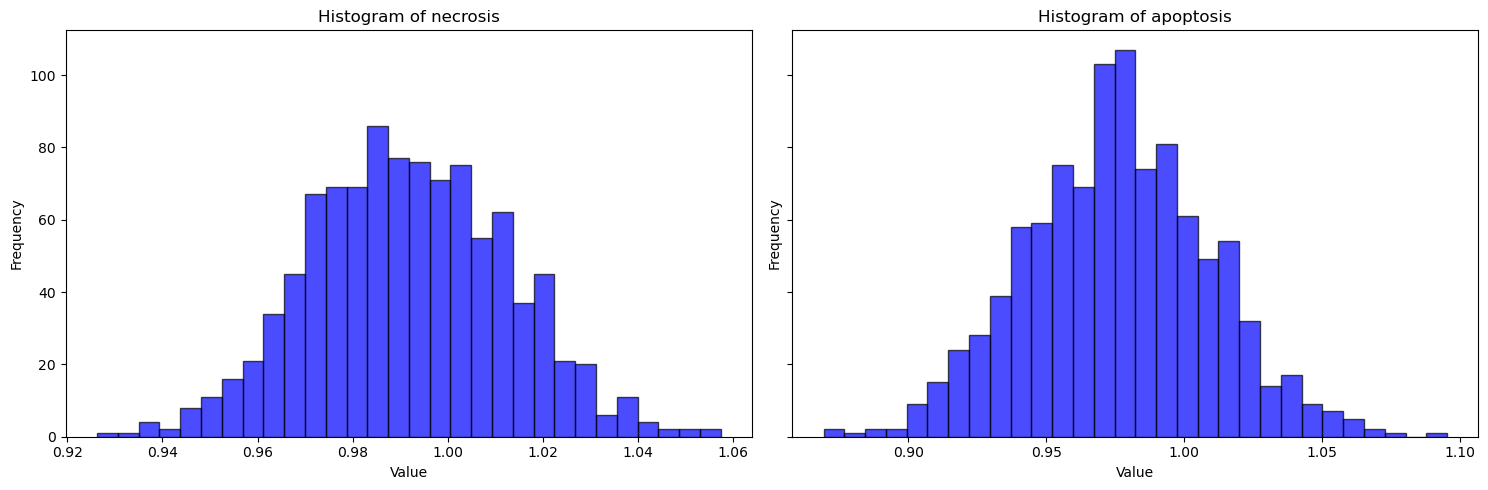

In [63]:
# Create subplots for each key in distr_dict
fig, axes = plt.subplots(nrows=1, ncols=len(distr_dict), figsize=(15, 5), sharey=True)

# Iterate over each key and its corresponding values in distr_dict
for ax, (key, value) in zip(axes, distr_dict.items()):
    ax.hist(value/ value[2], bins=30, alpha=0.7, color='blue', edgecolor='black')
    ax.set_title(f"Histogram of {key}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

In [ ]:
# Filter the data for a single origin
single_origin = "field14_two_colony"
origin_data = df[df['Origin'] == single_origin]

# Create a single subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Iterate over both necrosis and apoptosis
for mode in ['necrosis', 'apoptosis']:
    mode_data = origin_data[origin_data['Mode'] == mode]
    full_array = mode_data.iloc[0]['Shuffle Mean Full Arrays']
    observed_value = mode_data.iloc[0]['Observed']

    # Plot the histogram of the full array
    ax.hist(full_array, bins=30, alpha=0.5, color=custom_palette[f"{mode.capitalize()}InColonies"], 
            edgecolor='black', label=f"{mode.capitalize()} Histogram")

    # Add a red line for the observed value
    ax.axvline(observed_value, color='red', linestyle='--', linewidth=1, label=f"{mode.capitalize()} Observed")

# Add labels, title, and legend
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.set_title(f"Histogram of Full Array for {single_origin}")
ax.legend()
plt.tight_layout()
plt.show()


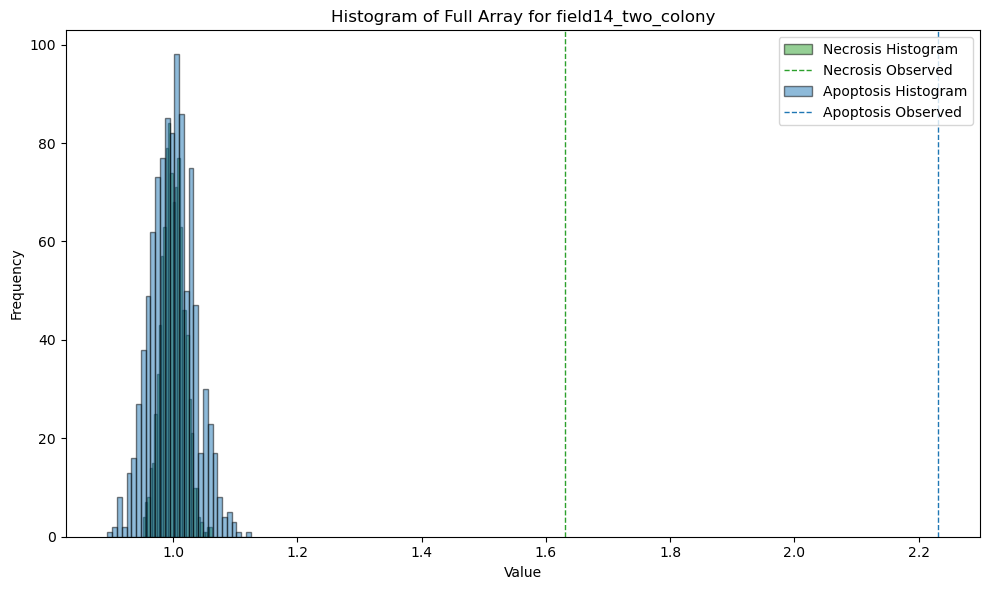

In [ ]:
# Filter the data for a single origin
custom_palette = {"apoptosis": "#1f77b4", "necrosis": "#2ca02c", "other": "lightgray"}


single_origin = "field14_two_colony"
origin_data = df[df['Origin'] == single_origin]

# Create a single subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Iterate over both necrosis and apoptosis
for mode in ['necrosis', 'apoptosis']:
    mode_data = origin_data[origin_data['Mode'] == mode]
    full_array = mode_data.iloc[0]['Shuffle Mean Full Arrays']
    observed_value = mode_data.iloc[0]['Observed']

    # Plot the histogram of the full array
    ax.hist(full_array/mode_data.iloc[0]['Expected'], bins=30, alpha=0.5, color=custom_palette[f"{mode}"], 
            edgecolor='black', label=f"{mode.capitalize()} Histogram")

    # Add a red line for the observed value
    ax.axvline(observed_value/mode_data.iloc[0]['Expected'], color=custom_palette[f"{mode}"], linestyle='--', linewidth=1, label=f"{mode.capitalize()} Observed")

# Add labels, title, and legend
ax.set_xlabel("Spatial Segregation Index (SI)")
ax.set_ylabel("Frequency")
ax.set_title(f"Histogram of Full Array for {single_origin}")
ax.legend()
plt.tight_layout()
plt.show()


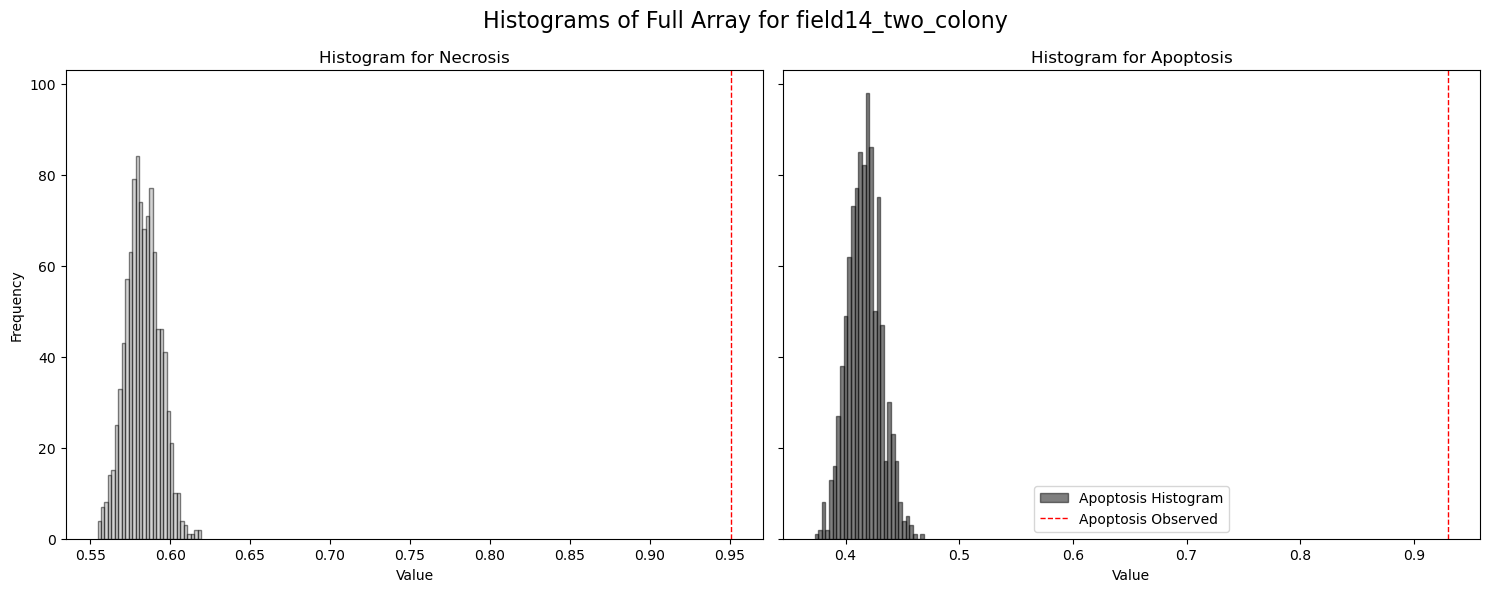

In [ ]:
# Filter the data for a single origin
single_origin = "field14_two_colony"
origin_data = df[df['Origin'] == single_origin]

# Create subplots for each mode
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharey=True)

# Iterate over both necrosis and apoptosis
for ax, mode in zip(axes, ['necrosis', 'apoptosis']):
    mode_data = origin_data[origin_data['Mode'] == mode]
    full_array = mode_data.iloc[0]['Shuffle Mean Full Arrays']
    observed_value = mode_data.iloc[0]['Observed']

    # Plot the histogram of the full array
    ax.hist(full_array, bins=30, alpha=0.5, color=custom_palette[f"{mode.capitalize()}InColonies"], 
            edgecolor='black', label=f"{mode.capitalize()} Histogram")

    # Add a red line for the observed value
    ax.axvline(observed_value, color='red', linestyle='--', linewidth=1, label=f"{mode.capitalize()} Observed")

    # Add labels, title, and legend
    ax.set_xlabel("Value")
    ax.set_title(f"Histogram for {mode.capitalize()}")

axes[0].set_ylabel("Frequency")
# fig.suptitle(f"Histograms of Full Array for {single_origin}", fontsize=16)
axes[-1].legend().
plt.tight_layout()
plt.show()


### Suppelmentry Fig of SSI

#### Fraction

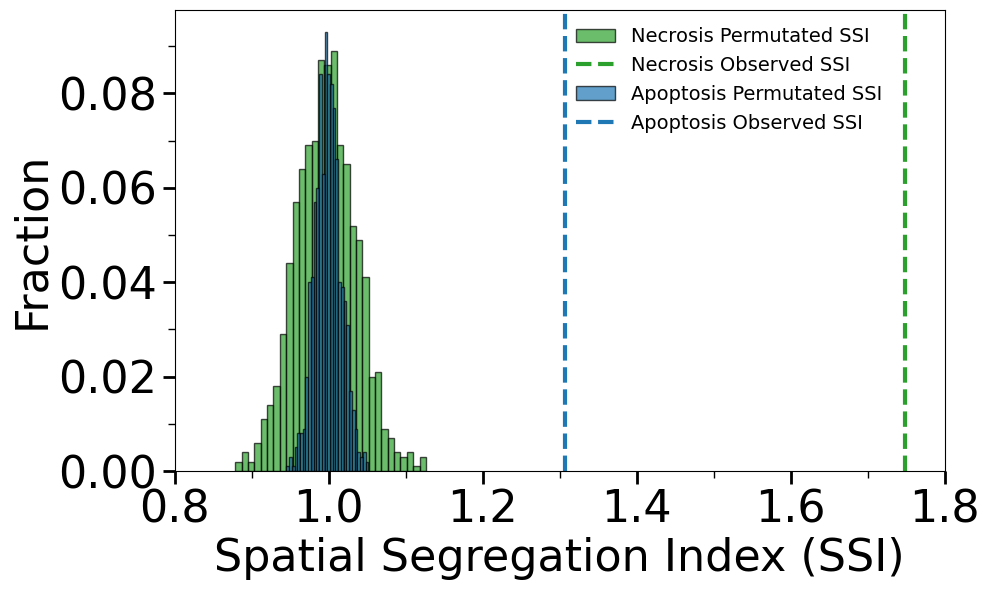

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Filter the data for a single origin
custom_palette =  {"apoptosis": "#1f77b4", "necrosis": "#2ca02c", "other": "lightgray"} #{"apoptosis": "#bf7745", "necrosis": "#f5e18a"} #

single_origin = "field14_colony"
origin_data = df[df['Origin'] == single_origin]

# Create a single subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Iterate over both necrosis and apoptosis
for mode in ['necrosis', 'apoptosis']:
    mode_data = origin_data[origin_data['Mode'] == mode]
    full_array = mode_data.iloc[0]['Shuffle Mean Full Arrays']
    observed_value = mode_data.iloc[0]['Observed']

    # Plot the histogram of the full array as a fraction of 1000
    ax.hist(
        full_array / mode_data.iloc[0]['Expected'],
        bins=30,
        alpha=0.7,
        color=custom_palette[f"{mode}"],
        edgecolor='black',
        label=f"{mode.capitalize()} Permutated SSI",
        weights=np.ones_like(full_array) / 1000  # Normalize to fraction of 1000
    )

    # Add a red line for the observed value
    ax.axvline(
        observed_value / mode_data.iloc[0]['Expected'],
        color=custom_palette[f"{mode}"],
        linestyle='--',
        linewidth=3,
        label=f"{mode.capitalize()} Observed SSI"
    )
    ax.set_facecolor('none')

# Add labels, title, and legend
ax.legend(frameon=False, fontsize=14, loc='upper center', bbox_to_anchor=(0.72, 1.0))

plt.gca().tick_params(axis='x', which='major', length=9, width=2, labelsize=32)
plt.gca().tick_params(axis='x', which='minor', length=5, width=1)
plt.gca().tick_params(axis='y', which='major', length=9, width=2, labelsize=32)
plt.gca().tick_params(axis='y', which='minor', length=5, width=1)
plt.gca().set_yticks(np.arange(0, 0.10, 0.01), minor=True)  # Adjusted for fractions
plt.gca().set_xticks(np.arange(0.8, 1.85, 0.1), minor=True)

plt.xlabel("Spatial Segregation Index (SSI)", fontsize=32)
plt.ylabel("Fraction", fontsize=32)  # Updated label
plt.grid(False)
plt.tight_layout()
plt.gca().set_facecolor('none')
plt.savefig("/home/esraan/CellDeathSpreading/results/ssi_fraction_nos_big.svg", format="svg", facecolor='none')
plt.show()

#### Count

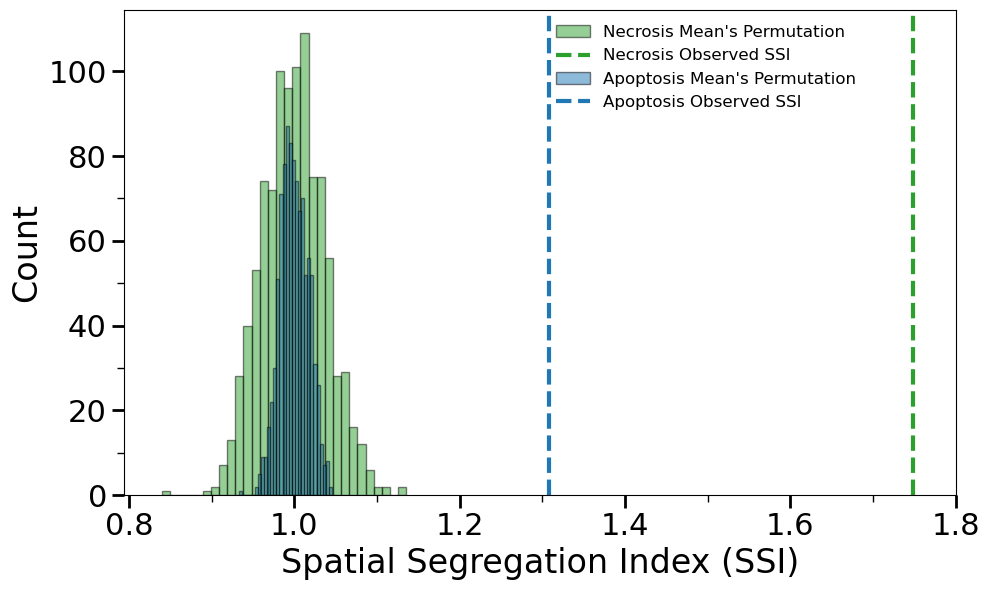

In [43]:
import matplotlib.pyplot as plt

# Filter the data for a single origin
custom_palette = {"apoptosis": "#1f77b4", "necrosis": "#2ca02c", "other": "lightgray"}

single_origin = "field14_colony"
origin_data = df[df['Origin'] == single_origin]

# Create a single subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Iterate over both necrosis and apoptosis
for mode in ['necrosis', 'apoptosis']:
    mode_data = origin_data[origin_data['Mode'] == mode]
    full_array = mode_data.iloc[0]['Shuffle Mean Full Arrays']
    observed_value = mode_data.iloc[0]['Observed']

    # Plot the histogram of the full array
    ax.hist(
        full_array / mode_data.iloc[0]['Expected'],
        bins=30,
        alpha=0.5,
        color=custom_palette[f"{mode}"],
        edgecolor='black',
        label=f"{mode.capitalize()} Mean's Permutation"
    )

    # Add a red line for the observed value
    ax.axvline(
        observed_value / mode_data.iloc[0]['Expected'],
        color=custom_palette[f"{mode}"],
        linestyle='--',
        linewidth=3,
        label=f"{mode.capitalize()} Observed SSI"
    )
    ax.set_facecolor('none')

# # Add labels, title, and legend
# ax.set_xlabel("Spatial Segregation Index (SI)")
# ax.set_ylabel("Count")
# ax.set_title(f"Histogram of Full Array for {single_origin}")
ax.legend( frameon=False, fontsize=12, loc='upper center', bbox_to_anchor=(0.7, 1.0))

# plt.xticks([0, 1], ['Apoptosis', 'Necrosis'], fontsize=24)
plt.gca().tick_params(axis='x', which='major', length=9, width=2, labelsize=22)
plt.gca().tick_params(axis='y', which='major', length=9, width=2, labelsize=22)
plt.gca().tick_params(axis='y', which='minor', length=5, width=1)
plt.gca().tick_params(axis='x', which='minor', length=5, width=1)
plt.gca().set_yticks(np.arange(0,90, 10), minor=True)
plt.gca().set_xticks(np.arange(0.8, 1.85,0.1), minor=True)
# plt.yticks(np.arange(0.0, 0.7, 0.05), fontsize=22)
# plt.yticks(fontsize = 22)
plt.xlabel("Spatial Segregation Index (SSI)", fontsize = 24)
plt.ylabel("Count", fontsize = 24)
# plt.title("SPI Values Across Treatments")
# plt.ylim(0.0, 90)
plt.grid(False)
plt.tight_layout()
plt.gca().set_facecolor('none')
plt.savefig("/home/esraan/CellDeathSpreading/results/ssi.svg", format="svg", facecolor='none')
plt.show()


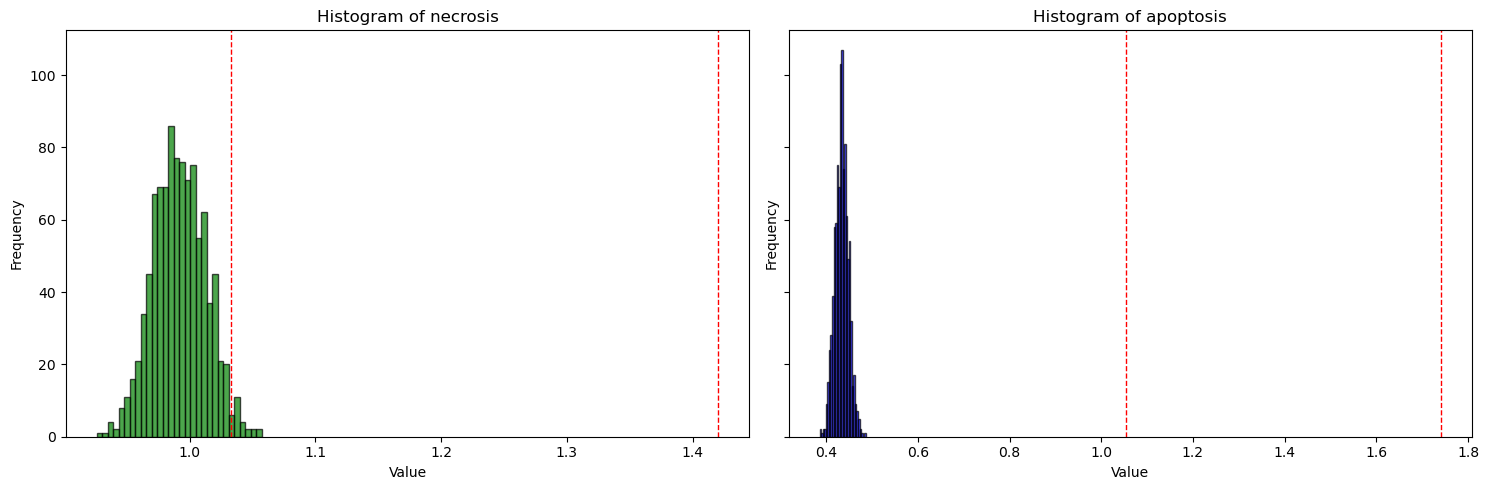

In [62]:
# Create subplots for each key in distr_dict
fig, axes = plt.subplots(nrows=1, ncols=len(distr_dict), figsize=(15, 5), sharey=True)

# Iterate over each key and its corresponding values in distr_dict
for ax, (key, value) in zip(axes, distr_dict.items()):
    if key == 'apoptosis':
        ax.hist(value , bins=30, alpha=0.7, color='blue', edgecolor='black')
    else:
        ax.hist(value / value[2], bins=30, alpha=0.7, color='green', edgecolor='black')
    ax.axvline(res_si[new_file][key][0], color='red', linestyle='--', linewidth=1, label='Observed SI')  # Add line for res[file]
    ax.axvline(per_5[new_file][key]/expected_lik[new_file][key], color='red', linestyle='--', linewidth=1, label='Observed SI') 
    ax.set_title(f"Histogram of {key}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    # ax.legend()

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

### PAPER SI

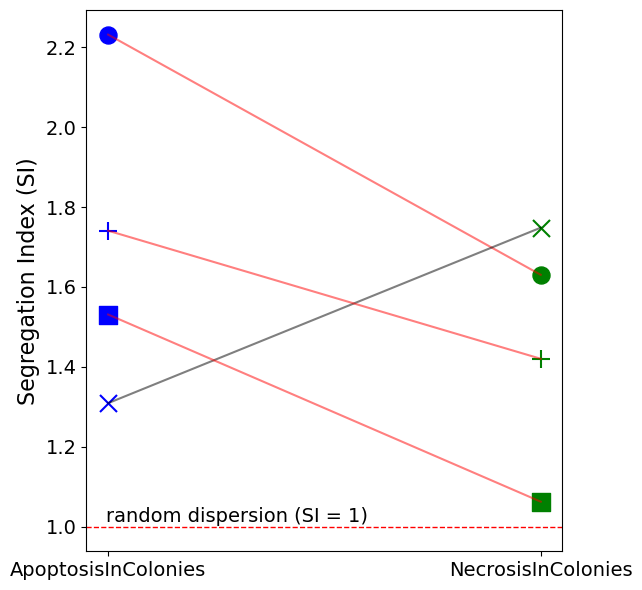

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
# Example data
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}
# Extract origins and corresponding values from plot_res_dict
origins = list(plot_res_dict.keys())
group_a_values = []
group_b_values = []
markers = ['o', 'x', 's', '+']
origin_marker_dict = {origin: markers[i % len(markers)] for i, origin in enumerate(origins)}

# Assign markers based on origin
origin_markers = [origin_marker_dict[origin] for origin in origins]
for origin, values in plot_res_dict.items():
    group_a = values.get('apoptosis', (np.nan,))[0]  # Get the first value for 'apoptosis'
    marker = origin_marker_dict[origin]  # Assign marker based on origin
    group_b = values.get('necrosis', (np.nan,))[0]   # Get the first value for 'necrosis'
    if not np.isnan(group_a) and not np.isnan(group_b):
        group_a_values.append(group_a)
        group_b_values.append(group_b)

# X positions: 0 for Group A, 1 for Group B
x_a = np.zeros(len(origins))
x_b = np.ones(len(origins))

# Plot
plt.figure(figsize=(6.5, 6))

for i in range(len(origins)):
    # Line connecting values 'r-' if group_a_values[i] < group_b_values[i]
    plt.plot([x_a[i], x_b[i]], [group_a_values[i], group_b_values[i]], 'r-' if group_a_values[i] > group_b_values[i] else 'k-', alpha=0.5)
    # Group A point
    plt.scatter(x_a[i], group_a_values[i], color=custom_palette['ApoptosisInColonies'], marker=origin_markers[i], label='ApoptosisInColonies' if i == 0 else "", s=150)
    # Group B point
    plt.scatter(x_b[i], group_b_values[i], color=custom_palette['NecrosisInColonies'], marker=origin_markers[i], label='NecrosisInColonies' if i == 0 else "", s=150)

# Create custom legend entries for markers
custom_legend = [Line2D([0], [0], marker=marker, color='k', markerfacecolor='k', markersize=10, label=origin)
                 for origin, marker in origin_marker_dict.items()]

plt.axhline(y=1, color='red', linestyle='--', linewidth=1,)
plt.text(0.60, 1.025, 'random dispersion (SI = 1)', color='black', fontsize=14, va='center', ha='right')
# Formatting
plt.xticks([0, 1], ['ApoptosisInColonies', 'NecrosisInColonies'], fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Segregation Index (SI)", fontsize = 16)
# plt.title("Segregation Index Across Origins")
plt.legend(handles=custom_legend, title="Origins", loc='upper right').remove()
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/SegregationIndexAcrossOrigins_noLegend.svg", format="svg")
plt.show()


### no LINE of perfecty SI

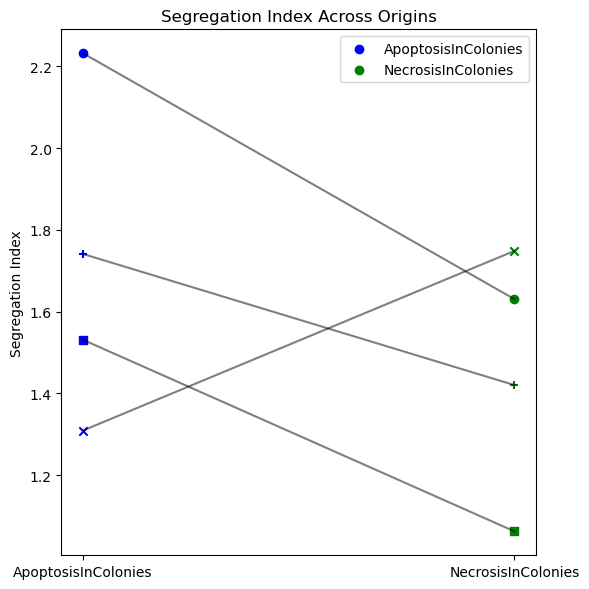

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Extract origins and corresponding values from plot_res_dict
origins = list(plot_res_dict.keys())
group_a_values = []
group_b_values = []
markers = ['o', 'x', 's', '+']
origin_marker_dict = {origin: markers[i % len(markers)] for i, origin in enumerate(origins)}

# Assign markers based on origin
origin_markers = [origin_marker_dict[origin] for origin in origins]
for origin, values in plot_res_dict.items():
    group_a = values.get('apoptosis', (np.nan,))[0]  # Get the first value for 'apoptosis'
    marker = origin_marker_dict[origin]  # Assign marker based on origin
    group_b = values.get('necrosis', (np.nan,))[0]   # Get the first value for 'necrosis'
    if not np.isnan(group_a) and not np.isnan(group_b):
        group_a_values.append(group_a)
        group_b_values.append(group_b)

# X positions: 0 for Group A, 1 for Group B
x_a = np.zeros(len(origins))
x_b = np.ones(len(origins))

# Plot
plt.figure(figsize=(6, 6))

for i in range(len(origins)):
    # Line connecting values
    plt.plot([x_a[i], x_b[i]], [group_a_values[i], group_b_values[i]], 'k-', alpha=0.5)
    # Group A point
    plt.scatter(x_a[i], group_a_values[i], color=custom_palette['ApoptosisInColonies'], marker=origin_markers[i], label='ApoptosisInColonies' if i == 0 else "")
    # Group B point
    plt.scatter(x_b[i], group_b_values[i], color=custom_palette['NecrosisInColonies'], marker=origin_markers[i], label='NecrosisInColonies' if i == 0 else "")
    # Origin label on the left
    # plt.text(-0.1, group_a_values[i], origins[i], va='center', ha='right', fontsize=9)

# Formatting
plt.xticks([0, 1], ['ApoptosisInColonies', 'NecrosisInColonies'])
plt.ylabel("Segregation Index")
plt.title("Segregation Index Across Origins")
plt.legend()#.remove()
plt.grid(False)
plt.tight_layout()
plt.show()


In [8]:
new_res = {'7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
'7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'}
plot_res_dict = {new_res.get(key):value for key,value in res.items()}

In [9]:
plot_res_dict

{'field14_two_colony': {'apoptosis': (np.float64(2.231776704676841),
   np.float64(0.0)),
  'necrosis': (np.float64(1.6304861624407918), np.float64(0.0))},
 'field14_colony': {'apoptosis': (np.float64(1.3091983949654762),
   np.float64(0.0)),
  'necrosis': (np.float64(1.7485063028937315), np.float64(0.0))},
 'field11_colony': {'apoptosis': (np.float64(1.531100045269353),
   np.float64(0.0)),
  'necrosis': (np.float64(1.0625830688355484), np.float64(0.0))},
 'field13_colony': {'necrosis': (np.float64(1.4203113708486506),
   np.float64(0.0)),
  'apoptosis': (np.float64(1.740928566765772), np.float64(0.0))}}

### SA in Segregation index

In [25]:

single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'
new_res = {'7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
'7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'}
# Define the distances to iterate over
distances = [33, 50, 100, 150, 200]
custom_palette = {
    'apoptosis': 'blue',
    'necrosis': 'green'
}
# Initialize a dictionary to store results for each distance
results_by_distance = {}

# Iterate over each distance
for dist in distances:
    res = {}
    for idx, file in enumerate(os.listdir(single_exp_full_paths)):
        if '_mixed' not in file:
            continue
        cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(
            exp_full_path=os.path.join(single_exp_full_paths, file)
        )
        exp_full_path = os.path.join(single_exp_full_paths, file)
        csv_file = pd.read_csv(exp_full_path)
        death_modes = csv_file[["Mode"]].values
        segregation_index = SegregationIdx(
            cells_loci, death_modes, 1000, dist, filter_neighbors_by_distance=True, neighbors_level=1, stats_to_calculate="mean"
        )
        seg_res_dict = segregation_index.get_segregation_index()
        res[file] = {key: (value[0] / value[2], value[1]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')}
    
    # Map file names to new_res dictionary
    plot_res_dict = {new_res.get(key): value for key, value in res.items()}
    results_by_distance[dist] = plot_res_dict

# # Plot results for each distance in subplots
# fig, axes = plt.subplots(nrows=1, ncols=len(distances), figsize=(20, 5), sharey=True)

# for i, dist in enumerate(distances):
#     ax = axes[i]
#     res = results_by_distance[dist]
#     files = list(res.keys())
#     modes = list(res[files[0]].keys())
#     mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

#     markers = ['o', 'x', 's', '+', '^', 'v']
#     # colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
#     # mode_color_dict = 
#     file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

#     for file_idx, file in enumerate(files):
#         for mode in modes:
#             ax.scatter(file_idx, res[file][mode], marker=file_marker_dict[file], color=custom_palette.get(mode, 'black'))#, label=f"{file} - {mode}" if file_idx == 0 else "")

#     ax.set_xticks(range(len(files)))
#     ax.set_xticklabels(files, rotation=45, ha='right', fontsize=8)
#     ax.set_title(f"Distance: {dist}", fontsize=12)
#     ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
#     ax.grid(False)

# fig.suptitle("Segregation Indices Across Distances", fontsize=16)
# fig.tight_layout(rect=[0, 0, 1, 0.95])
# fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')
# plt.show()


In [ ]:

single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'
new_res = {'7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
'7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'}
# Define the distances to iterate over
distances = [33, 50, 100, 150, 200]
custom_palette = {
    'apoptosis': 'blue',
    'necrosis': 'green'
}
# Initialize a dictionary to store results for each distance
results_by_distance = {}

# Iterate over each distance
for dist in distances:
    res = {}
    for idx, file in enumerate(os.listdir(single_exp_full_paths)):
        if '_mixed' not in file:
            continue
        cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(
            exp_full_path=os.path.join(single_exp_full_paths, file)
        )
        exp_full_path = os.path.join(single_exp_full_paths, file)
        csv_file = pd.read_csv(exp_full_path)
        death_modes = csv_file[["Mode"]].values
        segregation_index = SegregationIdx(
            cells_loci, death_modes, 1000, dist, filter_neighbors_by_distance=True, neighbors_level=1, stats_to_calculate="mean"
        )
        seg_res_dict = segregation_index.get_segregation_index()
        res[file] = {key: (value[0] / value[2], value[1]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')}
    
    # Map file names to new_res dictionary
    plot_res_dict = {new_res.get(key): value for key, value in res.items()}
    results_by_distance[dist] = plot_res_dict
# Plot results for each distance in subplots
fig, axes = plt.subplots(nrows=1, ncols=len(distances), figsize=(20, 5), sharey=True)

for i, dist in enumerate(distances):
    ax = axes[i]
    res = results_by_distance[dist]
    files = list(res.keys())
    modes = list(res[files[0]].keys())
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    markers = ['o', 'x', 's', '+', '^', 'v']
    # colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
    # mode_color_dict = 
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    for file_idx, file in enumerate(files):
        for mode in modes:
            # Extract the scalar value for y (first element of the tuple)
            y_value = res[file][mode][0] if isinstance(res[file][mode], tuple) else res[file][mode]
            ax.scatter(file_idx, y_value, marker=file_marker_dict[file], color=custom_palette.get(mode, 'black'))  # Ensure y_value is scalar

    ax.set_xticks(range(len(files)))
    ax.set_xticklabels(files, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"Distance: {dist}", fontsize=12)
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
    ax.grid(False)

fig.suptitle("Segregation Indices Across Distances", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()

/tmp/ipykernel_2123842/3908808356.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')


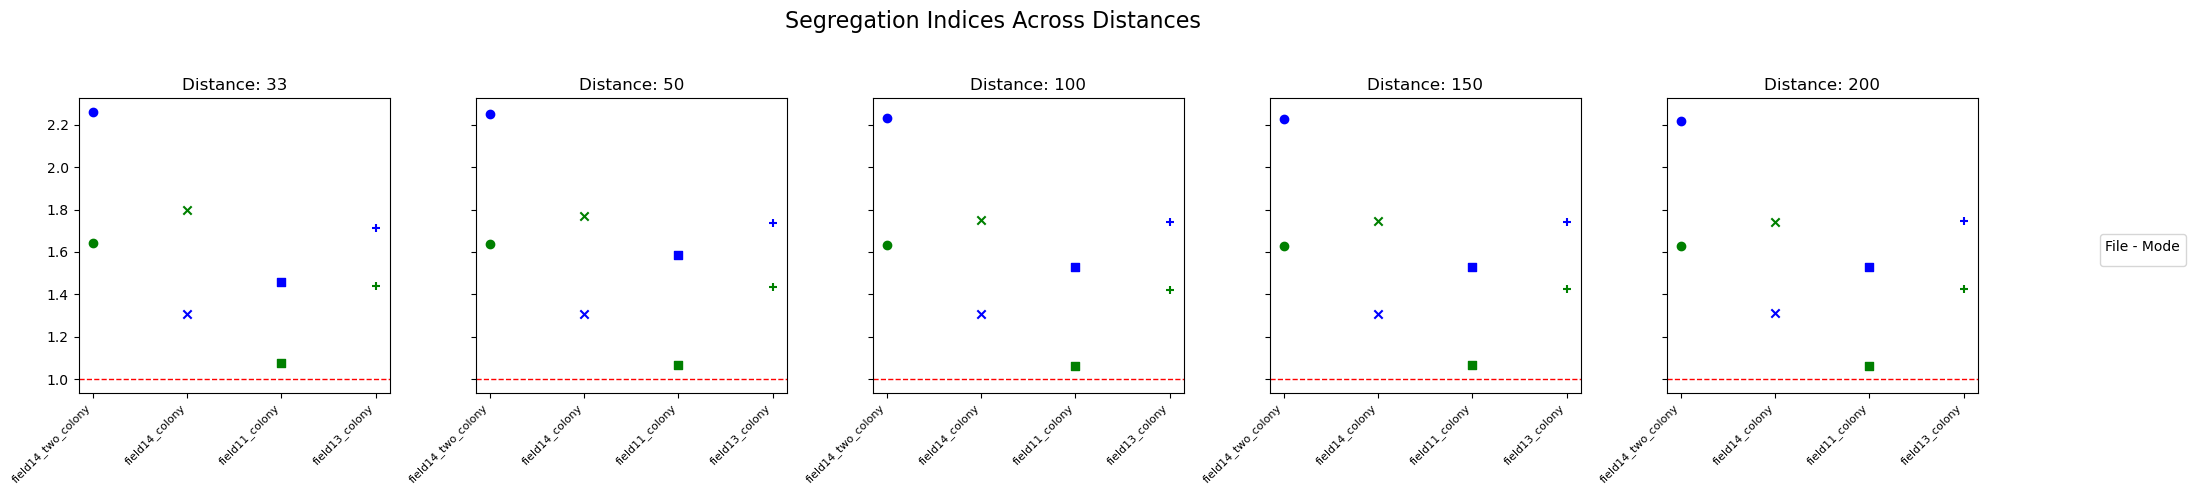

In [24]:

single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'
new_res = {'7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
'7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'}
# Define the distances to iterate over
distances = [33, 50, 100, 150, 200]
custom_palette = {
    'apoptosis': 'blue',
    'necrosis': 'green'
}
# Initialize a dictionary to store results for each distance
results_by_distance = {}

# Iterate over each distance
for dist in distances:
    res = {}
    for idx, file in enumerate(os.listdir(single_exp_full_paths)):
        if '_mixed' not in file:
            continue
        cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(
            exp_full_path=os.path.join(single_exp_full_paths, file)
        )
        exp_full_path = os.path.join(single_exp_full_paths, file)
        csv_file = pd.read_csv(exp_full_path)
        death_modes = csv_file[["Mode"]].values
        segregation_index = SegregationIdx(
            cells_loci, death_modes, 1000, dist, filter_neighbors_by_distance=True, neighbors_level=1, stats_to_calculate="mean"
        )
        seg_res_dict = segregation_index.get_segregation_index()
        res[file] = {key: (value[0] / value[2], value[1]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')}
    
    # Map file names to new_res dictionary
    plot_res_dict = {new_res.get(key): value for key, value in res.items()}
    results_by_distance[dist] = plot_res_dict
# Plot results for each distance in subplots
fig, axes = plt.subplots(nrows=1, ncols=len(distances), figsize=(20, 5), sharey=True)

for i, dist in enumerate(distances):
    ax = axes[i]
    res = results_by_distance[dist]
    files = list(res.keys())
    modes = list(res[files[0]].keys())
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    markers = ['o', 'x', 's', '+', '^', 'v']
    # colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
    # mode_color_dict = 
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    for file_idx, file in enumerate(files):
        for mode in modes:
            # Extract the scalar value for y (first element of the tuple)
            y_value = res[file][mode][0] if isinstance(res[file][mode], tuple) else res[file][mode]
            ax.scatter(file_idx, y_value, marker=file_marker_dict[file], color=custom_palette.get(mode, 'black'))  # Ensure y_value is scalar

    ax.set_xticks(range(len(files)))
    ax.set_xticklabels(files, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"Distance: {dist}", fontsize=12)
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
    ax.grid(False)

fig.suptitle("Segregation Indices Across Distances", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()

/tmp/ipykernel_2123842/1875366834.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')


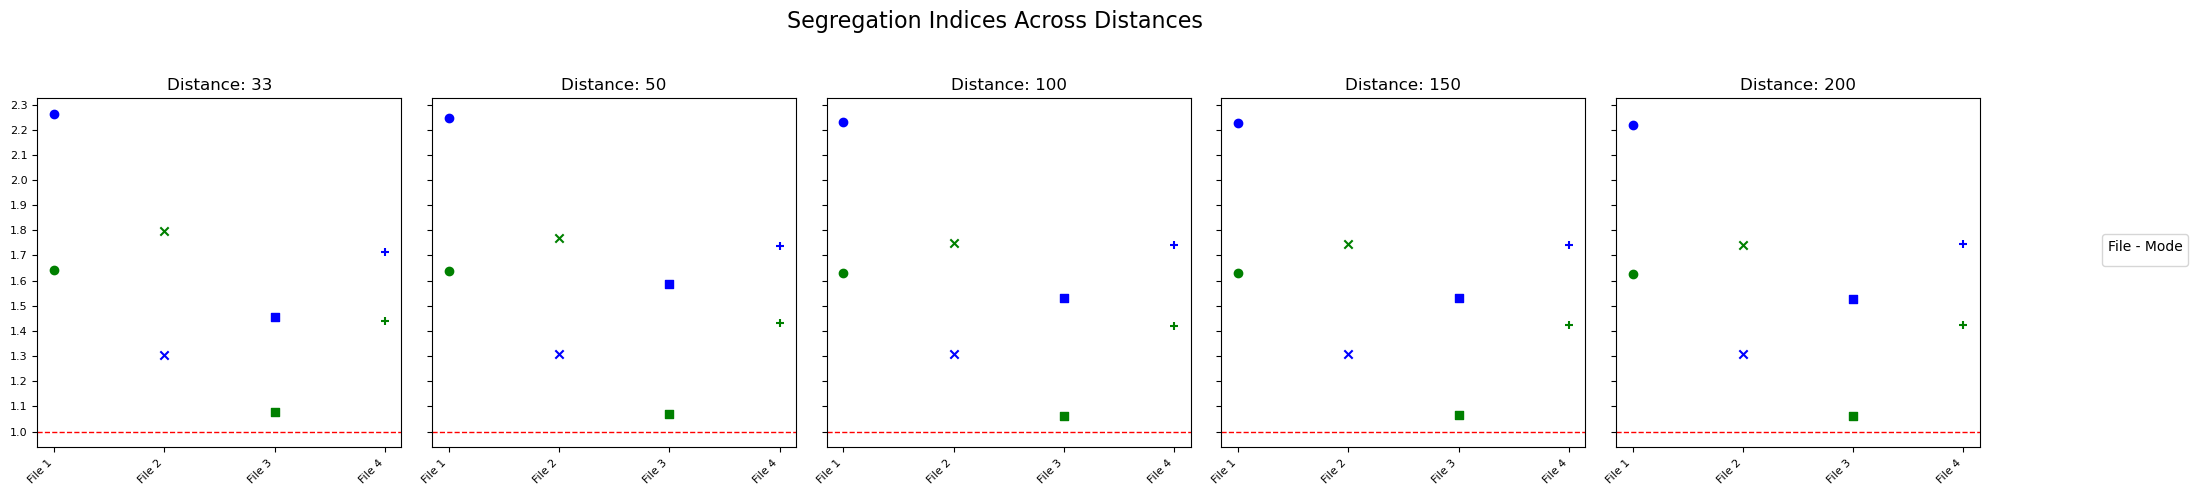

In [20]:
# Plot results for each distance in subplots
fig, axes = plt.subplots(nrows=1, ncols=len(distances), figsize=(20, 5), sharey=True)

for i, dist in enumerate(distances):
    ax = axes[i]
    res = results_by_distance[dist]
    files = list(res.keys())
    modes = list(res[files[0]].keys())
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    markers = ['o', 'x', 's', '+', '^', 'v']
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    for file_idx, file in enumerate(files):
        for mode in modes:
            # Extract the scalar value for y (first element of the tuple)
            y_value = res[file][mode][0] if isinstance(res[file][mode], tuple) else res[file][mode]
            ax.scatter(file_idx, y_value, marker=file_marker_dict[file], color=custom_palette.get(mode, 'black'))  # Ensure y_value is scalar

    # Add more ticks and replace axis contents
    ax.set_xticks(range(len(files)))
    ax.set_xticklabels([f"File {idx+1}" for idx in range(len(files))], rotation=45, ha='right', fontsize=8)
    ax.set_yticks([1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3])
    ax.set_yticklabels([f"{tick:.1f}" for tick in [1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3]], fontsize=8)

    ax.set_title(f"Distance: {dist}", fontsize=12)
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
    ax.grid(False)

fig.suptitle("Segregation Indices Across Distances", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()


In [16]:
# Convert the res dictionary into a DataFrame
# Flatten the results_by_distance dictionary into a DataFrame
results_flat = {
    (distance, file, mode): values[0]
    for distance, files in results_by_distance.items()
    for file, modes in files.items()
    for mode, values in modes.items()
}

# Convert the flattened dictionary into a DataFrame
res_df = pd.DataFrame.from_dict(results_flat, orient='index', columns=['SegregationIndex'])

# Reset the index to make it more readable
res_df.index = pd.MultiIndex.from_tuples(res_df.index, names=["Distance", "File", "Mode"])
res_df.reset_index(inplace=True)

# Display the resulting DataFrame
print(res_df)
res_df.to_csv("/home/esraan/CellDeathSpreading/results/SegregationIndicesByDistance.csv", index=False)

    Distance                File       Mode  SegregationIndex
0         33  field14_two_colony  apoptosis          2.261463
1         33  field14_two_colony   necrosis          1.643763
2         33      field14_colony  apoptosis          1.305017
3         33      field14_colony   necrosis          1.797183
4         33      field11_colony  apoptosis          1.455930
5         33      field11_colony   necrosis          1.076661
6         33      field13_colony   necrosis          1.439822
7         33      field13_colony  apoptosis          1.714494
8         50  field14_two_colony  apoptosis          2.248334
9         50  field14_two_colony   necrosis          1.638175
10        50      field14_colony  apoptosis          1.306559
11        50      field14_colony   necrosis          1.767536
12        50      field11_colony  apoptosis          1.585899
13        50      field11_colony   necrosis          1.068441
14        50      field13_colony   necrosis          1.432592
15      

In [ ]:
# Convert the res dictionary into a DataFrame
# Flatten the results_by_distance dictionary into a DataFrame
results_flat = {
    (distance, file, mode): values[0]
    for distance, files in results_by_distance.items()
    for file, modes in files.items()
    for mode, values in modes.items()
}

# Convert the flattened dictionary into a DataFrame
res_df = pd.DataFrame.from_dict(results_flat, orient='index', columns=['SegregationIndex'])

# Reset the index to make it more readable
res_df.index = pd.MultiIndex.from_tuples(res_df.index, names=["Distance", "File", "Mode"])
res_df.reset_index(inplace=True)

# Display the resulting DataFrame
print(res_df)
# res_df = pd.DataFrame.from_dict({(file, mode): values[0] for file, modes in res.items() for mode, values in modes.items()}, orient='index', columns=['SegregationIndex'])

# # Reset the index to make it more readable
# res_df.index = pd.MultiIndex.from_tuples(res_df.index, names=["File", "Mode"])
# res_df.reset_index(inplace=True)

# # Display the resulting DataFrame
# print(res_df)

                 File       Mode  SegregationIndex
0  field14_two_colony  apoptosis          2.219085
1  field14_two_colony   necrosis          1.626192
2      field14_colony  apoptosis          1.310033
3      field14_colony   necrosis          1.742691
4      field11_colony  apoptosis          1.527026
5      field11_colony   necrosis          1.063833
6      field13_colony   necrosis          1.422898
7      field13_colony  apoptosis          1.745881


/tmp/ipykernel_1225859/727173049.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')


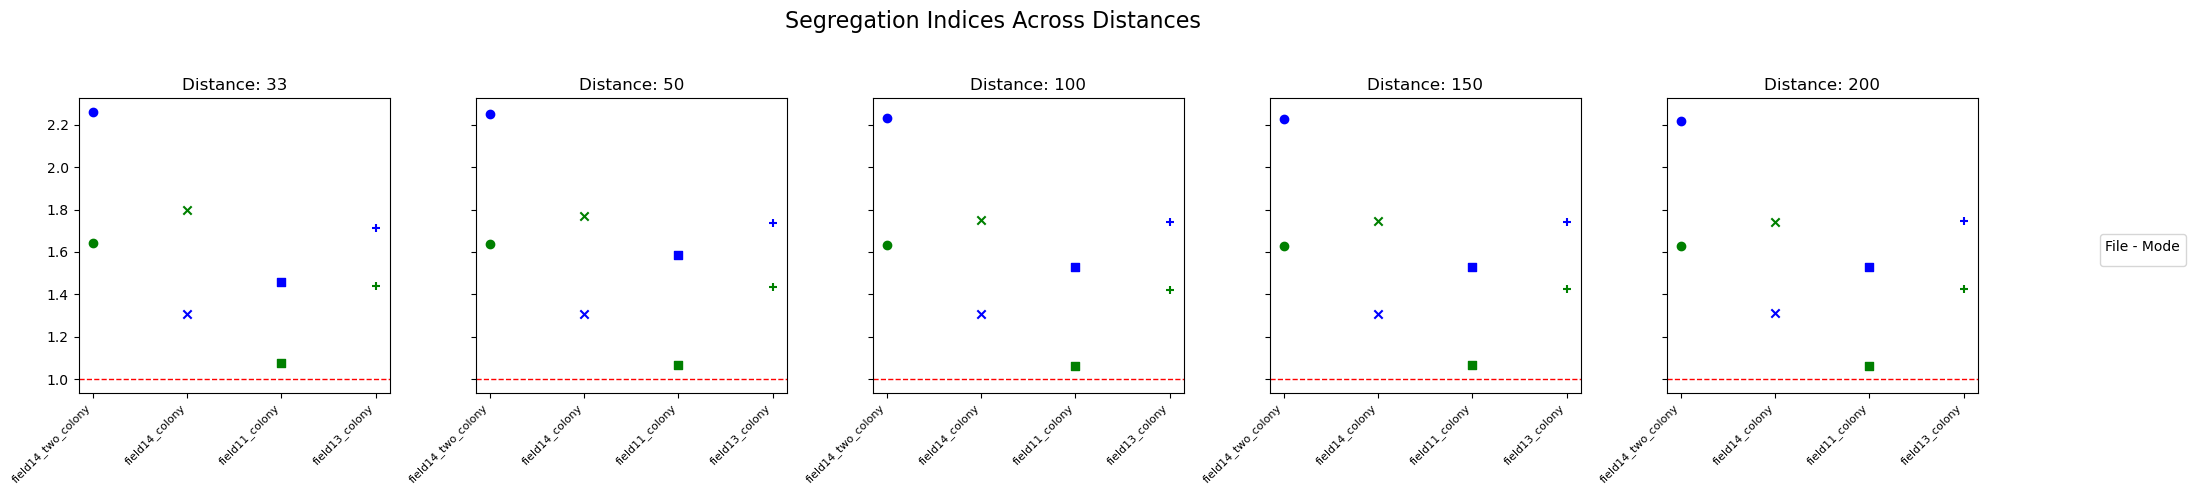

In [24]:
# Plot results for each distance in subplots
fig, axes = plt.subplots(nrows=1, ncols=len(distances), figsize=(20, 5), sharey=True)

for i, dist in enumerate(distances):
    ax = axes[i]
    res = results_by_distance[dist]
    files = list(res.keys())
    modes = list(res[files[0]].keys())
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    markers = ['o', 'x', 's', '+', '^', 'v']
    # colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
    # mode_color_dict = 
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    for file_idx, file in enumerate(files):
        for mode in modes:
            # Extract the scalar value for y (first element of the tuple)
            y_value = res[file][mode][0] if isinstance(res[file][mode], tuple) else res[file][mode]
            ax.scatter(file_idx, y_value, marker=file_marker_dict[file], color=custom_palette.get(mode, 'black'))  # Ensure y_value is scalar

    ax.set_xticks(range(len(files)))
    ax.set_xticklabels(files, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"Distance: {dist}", fontsize=12)
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
    ax.grid(False)

fig.suptitle("Segregation Indices Across Distances", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()